In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from tqdm.auto import tqdm
from torchmetrics.classification import MulticlassAccuracy

/Users/kuroyami/Desktop/NeuralNetworks/MachineLearning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    train = True,
    download = True,
    target_transform = None
)

test = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    download = True,
    train = False,
    target_transform = None
)

In [3]:
len(train), len(test)

(60000, 10000)

In [4]:
train_loader = DataLoader(train, batch_size = 64, shuffle = True)
test_loader = DataLoader(test, batch_size = 64, shuffle = False)

In [5]:
image, label = next(iter(train_loader))

In [6]:
classnames = train.classes

Text(0.5, 1.0, 'Dress')

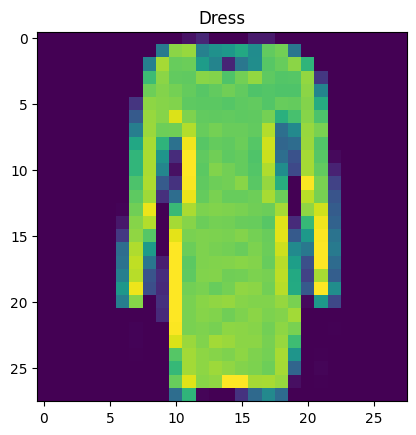

In [7]:
plt.imshow(image[0].squeeze())
plt.title(classnames[label[0]])

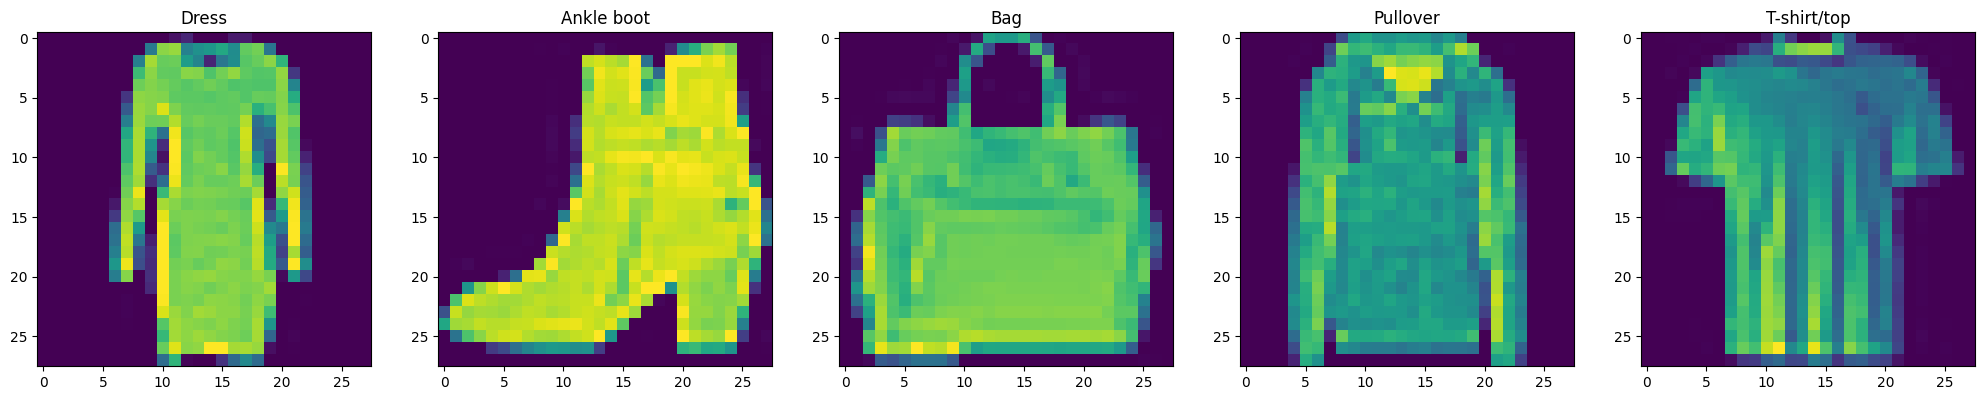

In [8]:
plt.figure(figsize = (25, 20))
for i in range(5):
    # random_idx = torch.randint(0, len(train_loader), size = (1,)).item()
    plt.subplot(1, 5, i + 1)
    plt.imshow(image[i].squeeze())
    plt.title(classnames[label[i]])

In [20]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, in_features: int = 784, out_features: int = 10, hidden_units: int = 128, batch_units: int = 64):
        super(FashionMNISTModel, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.batch_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [21]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [22]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [23]:
model = FashionMNISTModel(in_features = 784).to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [24]:
def train_model(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              dataset,
              device: torch.device = "cpu"
    ):

    running_loss, running_acc = 0.0, 0.0
    losses, total_accuracy = [], []

    model.train()
    accuracy_fn.reset()

    for idx, (image, target) in enumerate(dataset):
        target_logits = model(image.to(device))
        # train_accuracy = accuracy_fn.update(target, target_logits.argmax(dim = 1).to(device))

        loss = loss_fn(target_logits, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        train_accuracy = accuracy_fn.update(target.to(device), target_logits.argmax(dim = 1))
        running_loss += loss.item()
        # running_acc += accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item()

    avg_running_loss = running_loss / len(dataset)
    avg_running_acc = accuracy_fn.compute().item()
    
    # losses.append(loss.item())
    # total_accuracy.append(avg_running_acc)

    # if idx % (0.1 * len(dataset)) == 0:
        # print(f"Training Loss: {avg_running_loss} | Training Accuracy: {avg_running_acc}")
    print(f"Training Loss: {avg_running_loss} | Training Accuracy: {avg_running_acc}")

    return {
        "model": model.__class__.__name__,
        "running_loss": avg_running_loss,
        "running_accuracy": avg_running_acc
        # "losses": losses,
        # "total_accuracy": total_accuracy
    }

In [25]:
def test_model(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              dataset,
              accuracy_fn,
              device: torch.device = "cpu"
    ):

    running_loss, running_acc = 0.0, 0.0
    losses, total_accuracy = [], []

    accuracy_fn.reset()
    model.eval()
    with torch.inference_mode():
        for idx, (image, target) in enumerate(dataset):
            target_logits = model(image.to(device))

            loss = loss_fn(target_logits, target.to(device))
            # optimizer.zero_grad()

            # loss.backward()
            # optimizer.step()

            test_accuracy = accuracy_fn.update(target.to(device), target_logits.argmax(dim = 1))
            running_loss += loss.item()
            # running_accuracy += test_accuracy.update(target, test_accuracy)
            # running_acc += accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item()

        avg_loss = running_loss / len(dataset)
        avg_accuracy = accuracy_fn.compute().item()

        # losses.append(loss.item())
        # total_accuracy.append(accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item())

        # if idx % (0.1 * len(dataset)) == 0:
            # print(f"Testing Loss: {avg_loss} | Testing Accuracy: {avg_accuracy}")
        print(f"Testing Loss: {avg_loss} | Testing Accuracy: {avg_accuracy}\n")

        return {
            "model": model.__class__.__name__,
            "running_loss": avg_loss,
            "running_accuracy": avg_accuracy
            # "losses": losses,
            # "total_accuracy": total_accuracy
        }

In [26]:
def eval_model(model: torch.nn.Module,
              dataset,
              device
    ):
    model.train()

    with torch.inference_mode():
        for idx, (image, target) in enumerate(dataset):
            target_pred = model(image.to(device))

        return target_pred

In [27]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [28]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [29]:
from timeit import default_timer as timer
# import torch

def calculate_time(start: float, end: float, device: torch.device | str = "cpu", label: str = "") -> float:
    total = end - start

    label_info = f" for {label}" if label else ""
    device_name = device if isinstance(device, str) else device.type

    print(f"⏱️ Time taken{label_info}: {total:.3f} seconds on device: {device_name}")

    return total

In [30]:
epochs = 10

start = timer()

losses, total_accuracy, total_epochs = [], [], []
test_losses, test_total_accuracy = [], []

for epoch in tqdm(range(epochs)):
    model0_train = train_model(model = model,
                       loss_fn = loss_fn,
                       optimizer = optimizer,
                       accuracy_fn = accuracy_fn,
                       device = device,
                       dataset = train_loader)

    losses.append(model0_train["running_loss"])
    total_accuracy.append(model0_train["running_accuracy"])

    model0_test = test_model(model = model,
                       loss_fn = loss_fn,
                       optimizer = optimizer,
                       accuracy_fn = accuracy_fn,
                       device = device,
                       dataset = test_loader)

    test_losses.append(model0_test["running_loss"])
    test_total_accuracy.append(model0_test["running_accuracy"])

    total_epochs.append(epoch)

    # if epoch % (0.1 * len(epochs)) == 0:
    #     ...

end = timer()
calculate_time(start, end, device)

  0%|                                                    | 0/10 [00:00<?, ?it/s]

Training Loss: 0.5526206653191845 | Training Accuracy: 0.8038852214813232


 10%|████▍                                       | 1/10 [00:13<01:57, 13.03s/it]

Testing Loss: 0.43957406472248634 | Testing Accuracy: 0.8497709631919861

Training Loss: 0.3917134513161076 | Training Accuracy: 0.8595867156982422


 20%|████████▊                                   | 2/10 [00:21<01:21, 10.13s/it]

...

 90%|███████████████████████████████████████▌    | 9/10 [00:46<00:03,  3.85s/it]

Testing Loss: 0.33923272589209735 | Testing Accuracy: 0.8805491328239441

Training Loss: 0.26283764538925086 | Training Accuracy: 0.9022608995437622


100%|███████████████████████████████████████████| 10/10 [00:52<00:00,  5.29s/it]

Testing Loss: 0.3619328282631127 | Testing Accuracy: 0.873082160949707

⏱️ Time taken: 52.918 seconds on device: mps


52.91789333301131

In [31]:
df = pd.DataFrame([total_epochs, losses, total_accuracy])
df

,0,1,2,3,4,5,6,7,8,9
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000
1,0.552621,0.391713,0.353817,0.329885,0.314351,0.299096,0.288809,0.276925,0.271000,0.262838
2,0.803885,0.859587,0.872163,0.878758,0.884354,0.890866,0.893022,0.898945,0.900713,0.902261


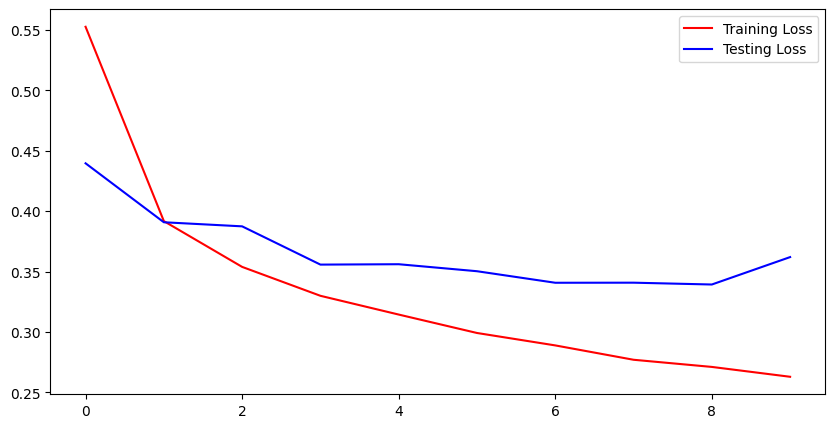

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, losses, label = "Training Loss", c = "red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c = "blue")
plt.legend()
plt.show()

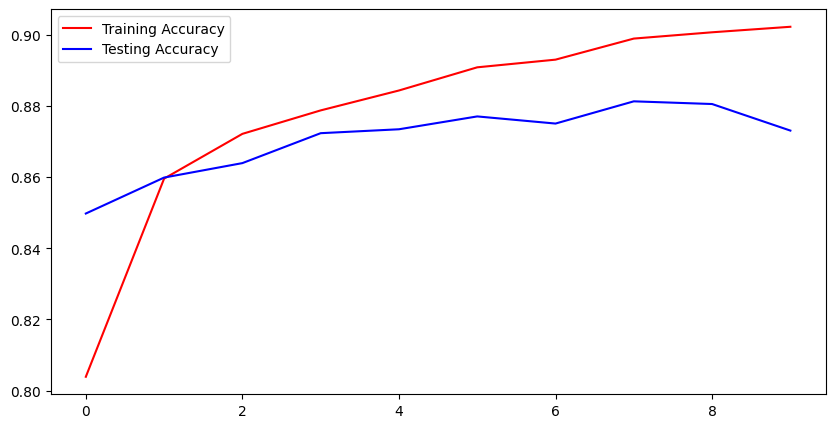

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, total_accuracy, label = "Training Accuracy", c = "red")
plt.plot(total_epochs, test_total_accuracy, label = "Testing Accuracy", c = "blue")
plt.legend()
plt.show()

In [53]:
class FashionMNISTModelV1(torch.nn.Module):
    def __init__(self, in_features: int = None, out_features: int = None, hidden_units: int = None, batch_units: int = None):
        super(FashionMNISTModelV1, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.batch_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2,
                              stride = 2)
        )
        self.linear_layer = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.batch_units*7*7,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        # print(x.shape)
        x = self.convolutional_layer2(x)
        # print(x.shape)
        x = self.linear_layer(x)
        
        # print(x.shape)
        return x

In [54]:
model1 = FashionMNISTModelV1(in_features = 1, out_features = len(classnames), hidden_units = 128, batch_units = 64).to(device)
model1

FashionMNISTModelV1(
  (convolutional_layer1): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=10, bias=True)
  )
)

In [55]:
# model1.eval()

# with torch.inference_mode():
#     for image, target in test_loader:
#         target_prediction = model1(image.to(device))

# target_prediction

In [56]:
dummy_target = torch.randn(size = (64, 28, 28))
# dummy_target

In [57]:
model.eval()
with torch.inference_mode():
    target_prediction = model(dummy_target.to(device))

# target_prediction

In [58]:
image.shape

torch.Size([64, 1, 28, 28])

In [59]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model1.parameters(), lr = 1e-3, weight_decay = 1e-5)

In [60]:
start = timer()

epochs = 5

total_epochs, losses, train_accuracy = [], [], []
test_losses, test_accuracy = [], []

for epoch in tqdm(range(epochs)):
    model1_train = train_model(model = model1,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = train_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

    losses.append(model1_train["running_loss"])
    train_accuracy.append(model1_train["running_accuracy"])

    model1_test = test_model(model = model1,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = test_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

    test_losses.append(model1_test["running_loss"])
    test_accuracy.append(model1_test["running_accuracy"])

    total_epochs.append(epoch)

end = timer()

calculate_time(start, end, device)

  0%|                                                     | 0/5 [00:00<?, ?it/s]

Training Loss: 0.4111779420964245 | Training Accuracy: 0.8505690097808838


 20%|█████████                                    | 1/5 [00:37<02:28, 37.15s/it]

Testing Loss: 0.33317873033748313 | Testing Accuracy: 0.8809607028961182

Training Loss: 0.25834692638915485 | Training Accuracy: 0.9066468477249146


 40%|██████████████████                           | 2/5 [01:07<01:40, 33.41s/it]

...

 80%|████████████████████████████████████         | 4/5 [02:14<00:33, 33.40s/it]

Testing Loss: 0.23594571317836738 | Testing Accuracy: 0.9166028499603271

Training Loss: 0.16954606171272424 | Training Accuracy: 0.9389657378196716


100%|█████████████████████████████████████████████| 5/5 [02:49<00:00, 33.81s/it]

Testing Loss: 0.23972082873628398 | Testing Accuracy: 0.9204356670379639

⏱️ Time taken: 169.040 seconds on device: mps


169.0403270839015

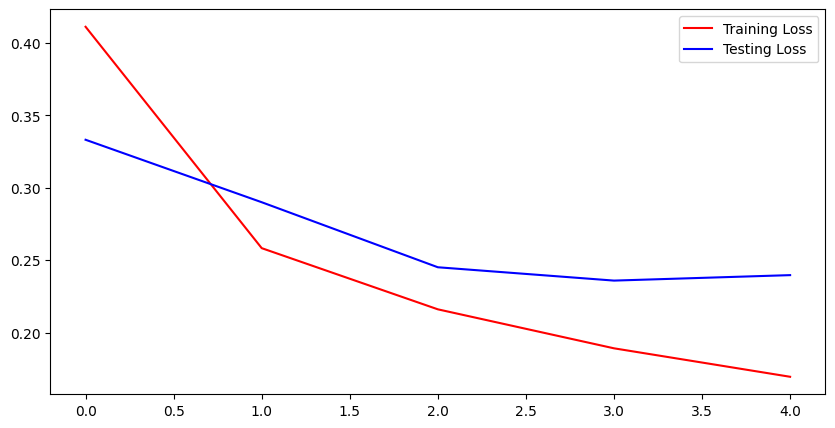

In [61]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, losses, label = "Training Loss", c = "red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c = "blue")
plt.legend()
plt.show()

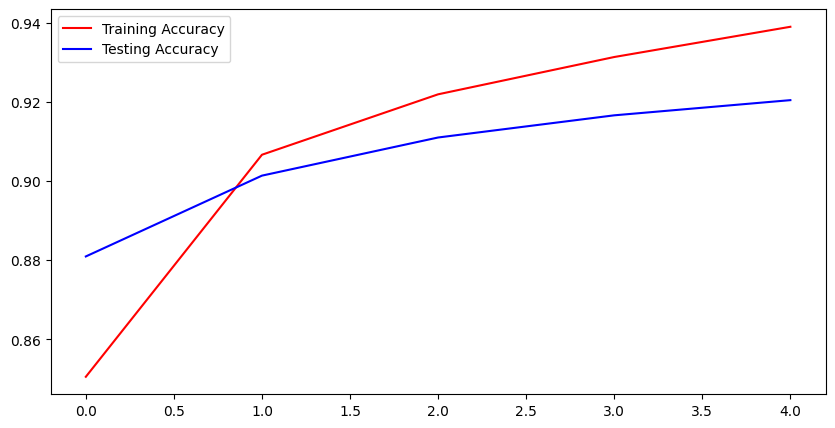

In [62]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, train_accuracy, label = "Training Accuracy", c = "red")
plt.plot(total_epochs, test_accuracy, label = "Testing Accuracy", c = "blue")
plt.legend()
plt.show()

In [63]:
class FashionMNISTModelV2(torch.nn.Module):
    def __init__(self,
                in_features: int = 1, # Grayscale image
                out_features: int = len(classnames),
                hidden_units: int = 128,
                batch_units: int = 64,
                drop_units: int = 32
        ):
        super(FashionMNISTModelV2, self).__init__()

        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units
        self.drop_units: int = drop_units
        
        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.BatchNorm2d(num_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            # torch.nn.BatchNorm2d(num_features = self.hidden_units)
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.BatchNorm2d(num_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 1),
            torch.nn.Dropout2d(p = 0.25)
        )

        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.BatchNorm2d(num_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.batch_units,
                           out_channels = self.batch_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d(p = 0.25)
        )
        self.convolutional_layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.batch_units,
                           out_channels = self.drop_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.BatchNorm2d(num_features = self.drop_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.drop_units,
                           out_channels = self.drop_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2),
            torch.nn.Dropout2d(p = 0.25)
        )

        # with torch.inference_mode():
        #     zeros = torch.zeros(1, self.in_features, 28, 28)
        #     cls_features = ...
            
        self.classification = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.drop_units * 7 * 7,
                           out_features = self.drop_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Dropout(p = 0.25),
            torch.nn.Linear(in_features = self.drop_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.tensor:
        x = self.convolutional_layer1(x)
        # print(x.shape)
        x = self.convolutional_layer2(x)
        # print(x.shape)
        x = self.convolutional_layer3(x)
        # print(x.shape)
        x = self.classification(x)
        return x

        # with torch.inference_mode():
        #     zeros = torch.zeros(1, self.in_features, 28, 28)
        #     cls
    

In [64]:
# torch.zeros(1, 1, 28, 28)

In [65]:
model2 = FashionMNISTModelV2().to(device)
model2

FashionMNISTModelV2(
  (convolutional_layer1): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (

In [66]:
# rand_image = torch.randn(size = (64, 1, 28, 28))

# target = model2(rand_image.to(device))
# target

In [48]:
optimizer = torch.optim.Adam(params = model2.parameters(), lr = 5e-4, weight_decay = 1e-4)

In [67]:
start = timer()

epochs = 5

total_epochs, losses, train_accuracy = [], [], []
test_losses, test_accuracy = [], []

for epoch in tqdm(range(epochs)):
    model2_train = train_model(model = model2,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = train_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

    losses.append(model2_train["running_loss"])
    train_accuracy.append(model2_train["running_accuracy"])

    model2_test = test_model(model = model2,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = test_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

    test_losses.append(model2_test["running_loss"])
    test_accuracy.append(model2_test["running_accuracy"])

    total_epochs.append(epoch)

end = timer()

calculate_time(start, end, device)

  0%|                                                     | 0/5 [00:00<?, ?it/s]

Training Loss: 2.3057437181981135 | Training Accuracy: 0.1085553988814354


 20%|█████████                                    | 1/5 [01:04<04:16, 64.07s/it]

Testing Loss: 2.304972634953298 | Testing Accuracy: 0.03393838182091713

Training Loss: 2.3051284976097057 | Training Accuracy: 0.13955584168434143


 40%|██████████████████                           | 2/5 [02:00<02:58, 59.48s/it]

...

 80%|████████████████████████████████████         | 4/5 [04:10<01:03, 63.39s/it]

Testing Loss: 2.305013222299564 | Testing Accuracy: 0.026344630867242813

Training Loss: 2.3054477167027847 | Training Accuracy: 0.131111279129982


100%|█████████████████████████████████████████████| 5/5 [05:15<00:00, 63.00s/it]

Testing Loss: 2.3049124638745737 | Testing Accuracy: 0.037111200392246246

⏱️ Time taken: 315.025 seconds on device: mps


315.0245739161037

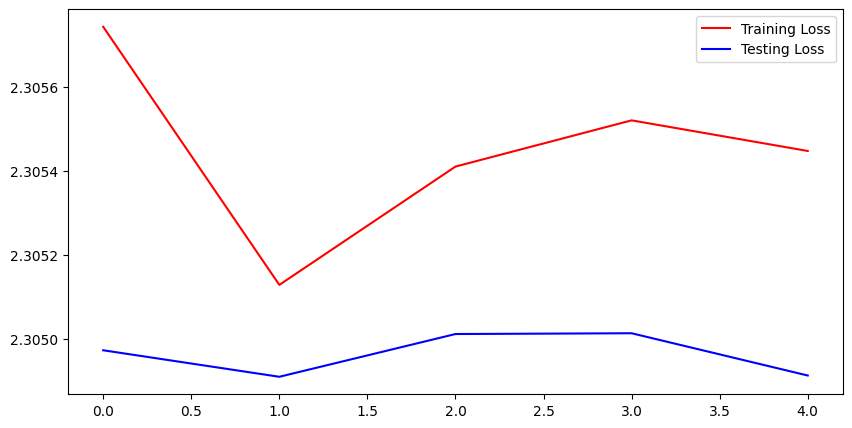

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, losses, label = "Training Loss", c = "red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c = "blue")
plt.legend()
plt.show()

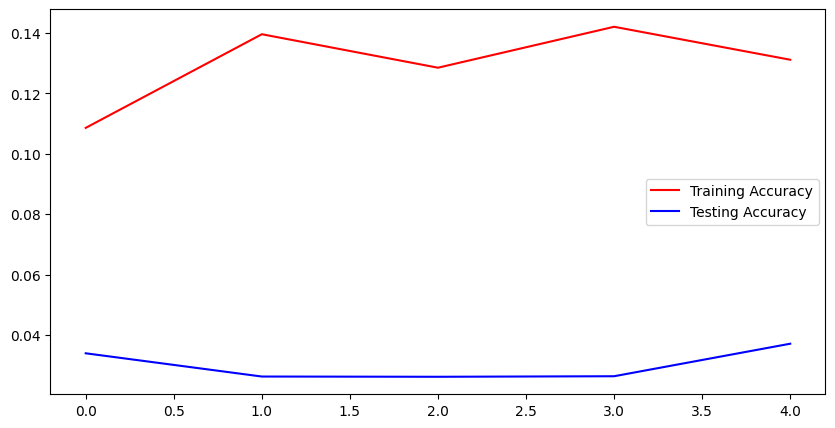

In [69]:
plt.figure(figsize=(10, 5))
plt.plot(total_epochs, train_accuracy, label = "Training Accuracy", c = "red")
plt.plot(total_epochs, test_accuracy, label = "Testing Accuracy", c = "blue")
plt.legend()
plt.show()